In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df=pd.read_csv("Employee.csv")
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


In [2]:
df.shape

(148, 6)

In [3]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [5]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [6]:
df.describe(include="all")

,Company,Age,Salary,Place,Country,Gender
count,140,130.000000,124.000000,134,148,148.000000
unique,6,NaN,NaN,11,1,NaN
top,TCS,NaN,NaN,Mumbai,India,NaN
freq,53,NaN,NaN,37,148,NaN
mean,NaN,30.484615,5312.467742,NaN,NaN,0.222973
std,NaN,11.096640,2573.764683,NaN,NaN,0.417654
min,NaN,0.000000,1089.000000,NaN,NaN,0.000000
25%,NaN,22.000000,3030.000000,NaN,NaN,0.000000
50%,NaN,32.500000,5000.000000,NaN,NaN,0.000000
75%,NaN,37.750000,8000.000000,NaN,NaN,0.000000


In [ ]:
df.isnull().sum()

In [ ]:
#. Data Exploration: (Score : 2)
#● Explore the data, list down the unique values in each feature and find its length.
#● Perform the statistical analysis and renaming of the columns.

In [7]:
#Explore the data, list down the unique values in each feature and find its length.
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("Length:", len(df[col].unique()))
    print()

Company
['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length: 7

Age
[20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 30

Salary
[  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length: 41

Place
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length: 12

Country
['India']
Length: 1

Gender
[0 1]
Length: 2



In [8]:
#Perform the statistical analysis 
print("Mean:\n",df.mean(numeric_only=True))
print("Median:\n",df.median(numeric_only=True))
print("Mode:\n",df.mode().iloc[0])
print("Standard Deviation:\n",df.std(numeric_only=True))
print("Variance:\n",df.var(numeric_only=True))

Mean:
 Age         30.484615
Salary    5312.467742
Gender       0.222973
dtype: float64
Median:
 Age         32.5
Salary    5000.0
Gender       0.0
dtype: float64
Mode:
 Company       TCS
Age          22.0
Salary     3000.0
Place      Mumbai
Country     India
Gender          0
Name: 0, dtype: object
Standard Deviation:
 Age         11.096640
Salary    2573.764683
Gender       0.417654
dtype: float64
Variance:
 Age       1.231354e+02
Salary    6.624265e+06
Gender    1.744346e-01
dtype: float64


In [9]:
#renaming of the columns.
df.rename(columns={
    "Company":"company",
    "Age":"age",
    "Salary":"salary",
    "Place":"place",
    "Country":"country",
    "Gender":"gender"},inplace=True)

In [10]:
df.columns

Index(['company', 'age', 'salary', 'place', 'country', 'gender'], dtype='object')

In [ ]:
#2. Data Cleaning: (Score : 2)
#● Find the missing and inappropriate values, treat them appropriately.
#● Remove all duplicate rows.
#● Find the outliers.
#● Replace the value 0 in age as NaN Treat the null values in all columns using any measures(removing/ replace the values with mean/median/mode) 

In [11]:
df.isnull().sum()

company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64

In [12]:
#Filling missing values
df['company']=df['company'].fillna(df['company'].mode()[0])
df['salary']=df['salary'].fillna(np.mean(df['salary']))
df['place']=df['place'].fillna(df['place'].mode()[0])
df.isna().sum()

company     0
age        18
salary      0
place       0
country     0
gender      0
dtype: int64

In [13]:
df.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
143    False
144     True
145    False
146    False
147    False
Length: 148, dtype: bool>

In [14]:
df = df.drop_duplicates() # Remove duplicate rows
df

,company,age,salary,place,country,gender
0,TCS,20.0,5312.467742,Chennai,India,0
1,Infosys,30.0,5312.467742,Mumbai,India,0
2,TCS,35.0,2300.000000,Calcutta,India,0
3,Infosys,40.0,3000.000000,Delhi,India,0
4,TCS,23.0,4000.000000,Mumbai,India,0
...,...,...,...,...,...,...
142,Infosys Pvt Lmt,22.0,8202.000000,Mumbai,India,0
143,TCS,33.0,9024.000000,Calcutta,India,1
145,Infosys,44.0,4034.000000,Delhi,India,1
146,TCS,33.0,5034.000000,Mumbai,India,1


In [15]:
df.reset_index(drop=True)

,company,age,salary,place,country,gender
0,TCS,20.0,5312.467742,Chennai,India,0
1,Infosys,30.0,5312.467742,Mumbai,India,0
2,TCS,35.0,2300.000000,Calcutta,India,0
3,Infosys,40.0,3000.000000,Delhi,India,0
4,TCS,23.0,4000.000000,Mumbai,India,0
...,...,...,...,...,...,...
139,Infosys Pvt Lmt,22.0,8202.000000,Mumbai,India,0
140,TCS,33.0,9024.000000,Calcutta,India,1
141,Infosys,44.0,4034.000000,Delhi,India,1
142,TCS,33.0,5034.000000,Mumbai,India,1


In [16]:
df.shape

(144, 6)

In [19]:
df["age"] = df["age"].replace(0, np.nan) # Replace age = 0 with NaN
df["age"] = df["age"].fillna(df["age"].mean()) # Fill missing values
print(df.isnull().sum()) # Check missing values

company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_3316\712215021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age"] = df["age"].replace(0, np.nan) # Replace age = 0 with NaN
C:\Users\Dell\AppData\Local\Temp\ipykernel_3316\712215021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age"] = df["age"].fillna(df["age"].mean()) # Fill missing values


In [ ]:
#Finding outliers

<Axes: >

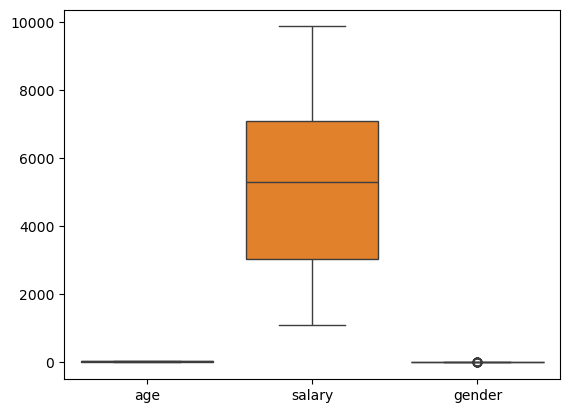

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(data=df)

Text(0.5, 1.0, 'Boxplot of salary')

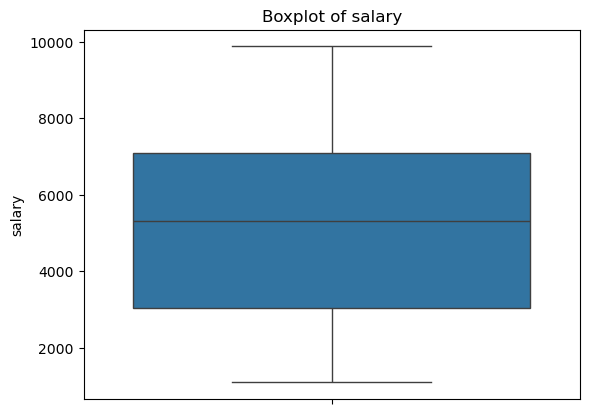

In [21]:
sns.boxplot(df['salary']) 
plt.title("Boxplot of salary")

In [22]:
Q1=np.percentile(df['salary'],25)
Q3=np.percentile(df['salary'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['salary']<lower_bound) | (df['salary']>upper_bound)]
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower_bound:",lower_bound)
print("Upper_bound:",upper_bound)
print("Number of outliers:",len(outliers))
outliers

Q1: 3045.0
Q3: 7084.0
IQR: 4039.0
Lower_bound: -3013.5
Upper_bound: 13142.5
Number of outliers: 0


,company,age,salary,place,country,gender


Text(0.5, 1.0, 'Boxplot of Age')

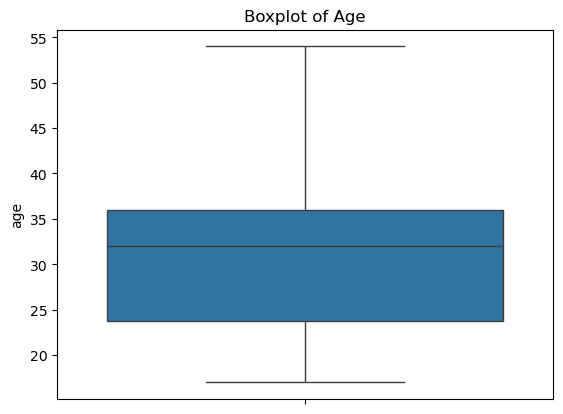

In [23]:
sns.boxplot(df["age"])
plt.title("Boxplot of Age")

In [24]:

Q1=np.percentile(df['age'],25)
Q3=np.percentile(df['age'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['age']<lower_bound) | (df['age']>upper_bound)]
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower_bound:",lower_bound)
print("Upper_bound:",upper_bound)
print("Number of outliers:",len(outliers))
outliers

Q1: 23.75
Q3: 36.0
IQR: 12.25
Lower_bound: 5.375
Upper_bound: 54.375
Number of outliers: 0


,company,age,salary,place,country,gender


Text(0.5, 1.0, 'Boxplot of Gender')

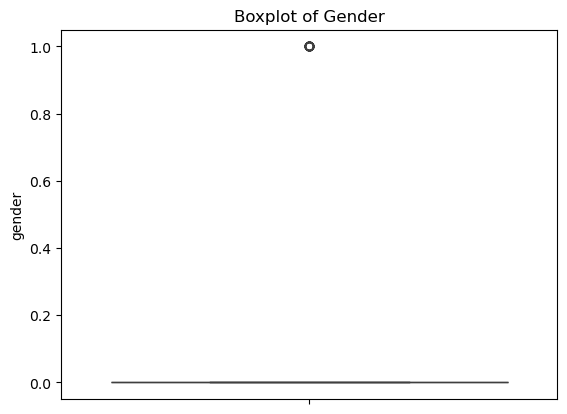

In [25]:
sns.boxplot(df['gender']) 
plt.title("Boxplot of Gender")

In [26]:
Q1=np.percentile(df['gender'],25)
Q3=np.percentile(df['gender'],75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['gender']<lower_bound) | (df['gender']>upper_bound)]
print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("Lower_bound:",lower_bound)
print("Upper_bound:",upper_bound)
print("Number of outliers:",len(outliers))
outliers

Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower_bound: 0.0
Upper_bound: 0.0
Number of outliers: 32


,company,age,salary,place,country,gender
6,TCS,32.041322,6000.0,Chennai,India,1
7,Infosys,23.000000,7000.0,Mumbai,India,1
8,TCS,34.000000,8000.0,Calcutta,India,1
24,TCS,32.041322,7084.0,Chennai,India,1
25,Infosys,23.000000,8943.0,Mumbai,India,1
26,TCS,34.000000,8345.0,Calcutta,India,1
27,CTS,45.000000,9284.0,Delhi,India,1
28,CTS,23.000000,9876.0,Mumbai,India,1
35,TCS,35.000000,9024.0,Mumbai,India,1
44,TCS,35.000000,8000.0,Noida,India,1


In [27]:
#3. Data Analysis: (Score : 2)
#● Filter the data with age >40 and salary<5000 Plot the chart with age and salary Count the number of people from each place and represent it visually

In [28]:
filteres_df=df[(df['age']>40) & (df['salary']<5000)]
filteres_df

,company,age,salary,place,country,gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
86,Infosys,41.0,3000.0,Delhi,India,0
93,Infosys,54.0,3184.0,Mumbai,India,0
104,Infosys,44.0,4034.0,Delhi,India,0


Text(0.5, 1.0, 'Age vs Salary')

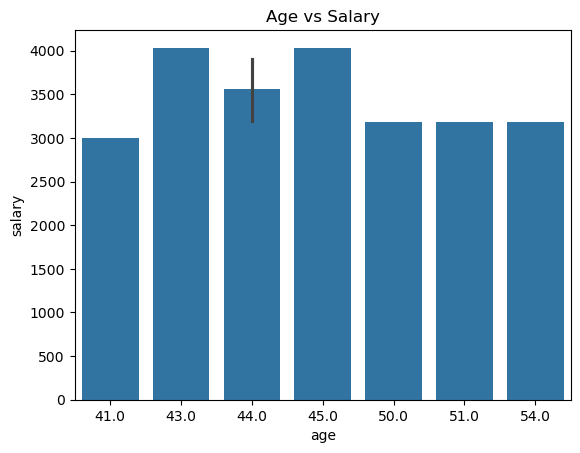

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(data=filteres_df,x="age",y="salary") #chart with age and salary
plt.title("Age vs Salary")

<Axes: xlabel='place', ylabel='count'>

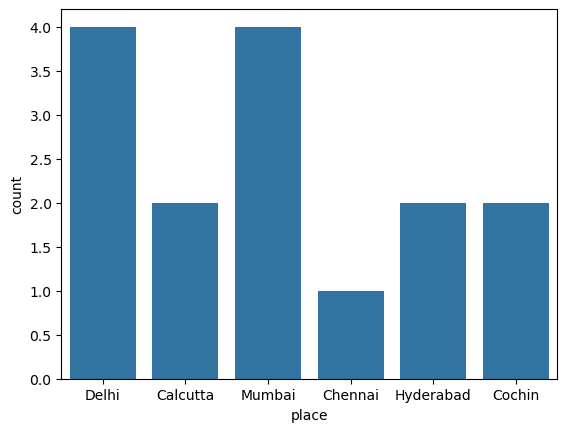

In [30]:
sns.countplot(data=filteres_df,x="place")# Count of the number of people from each place

In [31]:
#4. Data Encoding: (Score : 2)
#● Convert categorical variables into numerical representations using techniques such as one-hot encoding, label encoding, making them suitable for analysis by ML algorithms

In [32]:
df.select_dtypes(include='object').columns

Index(['company', 'place', 'country'], dtype='object')

In [33]:
#one hot encoding on Company
df = pd.get_dummies(df, columns=["company"], drop_first=True,dtype=int)
df

,age,salary,place,country,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services
0,20.0,5312.467742,Chennai,India,0,0,0,0,1,0
1,30.0,5312.467742,Mumbai,India,0,0,1,0,0,0
2,35.0,2300.000000,Calcutta,India,0,0,0,0,1,0
3,40.0,3000.000000,Delhi,India,0,0,1,0,0,0
4,23.0,4000.000000,Mumbai,India,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
142,22.0,8202.000000,Mumbai,India,0,0,0,1,0,0
143,33.0,9024.000000,Calcutta,India,1,0,0,0,1,0
145,44.0,4034.000000,Delhi,India,1,0,1,0,0,0
146,33.0,5034.000000,Mumbai,India,1,0,0,0,1,0


In [34]:
#one hot encoding on place
df = pd.get_dummies(df, columns=["place"], drop_first=True,dtype=int)
df

,age,salary,country,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,20.0,5312.467742,India,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
1,30.0,5312.467742,India,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,35.0,2300.000000,India,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
3,40.0,3000.000000,India,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
4,23.0,4000.000000,India,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,22.0,8202.000000,India,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
143,33.0,9024.000000,India,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
145,44.0,4034.000000,India,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
146,33.0,5034.000000,India,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [35]:
#one hot encoding on place
df = pd.get_dummies(df, columns=["country"], drop_first=True,dtype=int)
df

,age,salary,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,20.0,5312.467742,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
1,30.0,5312.467742,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,35.0,2300.000000,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
3,40.0,3000.000000,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
4,23.0,4000.000000,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,22.0,8202.000000,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
143,33.0,9024.000000,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
145,44.0,4034.000000,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
146,33.0,5034.000000,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,age,salary,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,20.0,5312.467742,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
1,30.0,5312.467742,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,35.0,2300.000000,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
3,40.0,3000.000000,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
4,23.0,4000.000000,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


In [39]:
#5. Feature Scaling: (Score : 2)
#● After the process of encoding, perform the scaling of the features using standardscaler and minmaxscaler.

In [40]:
#Standardascaling
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
df_scaled=scalar.fit_transform(df.select_dtypes(include="number"))
print(df_scaled)

[[-1.46737581  0.01032366 -0.53452248 ... -0.24253563 -0.14586499
  -0.11867817]
 [-0.24875897  0.01032366 -0.53452248 ... -0.24253563 -0.14586499
  -0.11867817]
 [ 0.36054944 -1.266072   -0.53452248 ... -0.24253563 -0.14586499
  -0.11867817]
 ...
 [ 1.4573046  -0.53136867  1.87082869 ... -0.24253563 -0.14586499
  -0.11867817]
 [ 0.11682608 -0.10766433  1.87082869 ... -0.24253563 -0.14586499
  -0.11867817]
 [-1.22365245  1.23463103 -0.53452248 ... -0.24253563 -0.14586499
  -0.11867817]]


In [41]:
#scaling using minmax scaler
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
df_minmax=scalar.fit_transform(df.select_dtypes(include="number"))
print(df_minmax)

[[0.08108108 0.48064957 0.         ... 0.         0.         0.        ]
 [0.35135135 0.48064957 0.         ... 0.         0.         0.        ]
 [0.48648649 0.13781723 0.         ... 0.         0.         0.        ]
 ...
 [0.72972973 0.33515421 1.         ... 0.         0.         0.        ]
 [0.43243243 0.44895869 1.         ... 0.         0.         0.        ]
 [0.13513514 0.80949129 0.         ... 0.         0.         0.        ]]
